# Food Delivery Data Analysis

## Objective
This notebook analyzes a food delivery dataset by integrating:
- Orders data (CSV)
- User master data (JSON)
- Restaurant master data (SQL)

The goal is to extract business insights related to:
- User behavior
- Revenue trends
- Membership impact
- Cuisine and restaurant performance


## 1. Import Libraries

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json


## 2. Load Orders CSV

In [30]:
orders = pd.read_csv("orders.csv")

## 3. Load Users JSON

In [31]:
with open("users.json", "r") as f:
    users_data = json.load(f)

users = pd.DataFrame(users_data)

## 4. Load Restaurants SQL

In [32]:
conn = sqlite3.connect(":memory:")

with open("restaurants.sql", "r") as f:
    sql_script = f.read()

conn.executescript(sql_script)

restaurants = pd.read_sql("SELECT * FROM restaurants", conn)

## 5. Merge datasets

In [33]:
df = orders.merge(users, on="user_id", how="left")
df = df.merge(restaurants, on="restaurant_id", how="left")

**Note:** LEFT JOINs were used to ensure no order-level data was lost during integration.


## 6. Save final dataset

In [34]:
df.to_csv("final_food_delivery_dataset.csv", index=False)

df.head()

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name_x,name,city,membership,restaurant_name_y,cuisine,rating
0,1,2508,450,18-02-2023,842.97,New Foods Chinese,User_2508,Hyderabad,Regular,Restaurant_450,Mexican,3.2
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine,User_2693,Pune,Regular,Restaurant_309,Indian,4.5
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi,User_2084,Chennai,Gold,Restaurant_107,Mexican,4.0
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg,User_319,Bangalore,Gold,Restaurant_224,Chinese,4.8
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian,User_1064,Pune,Regular,Restaurant_293,Italian,3.0


# Questions

## Q1. Which city has the highest total revenue (total_amount) from Gold members?


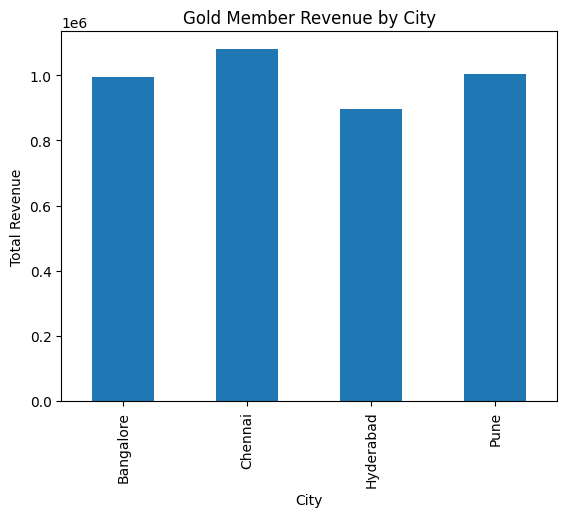

In [70]:
gold_city_revenue = (
    df[df['membership'] == 'Gold']
    .groupby('city')['total_amount']
    .sum()
)

plt.figure()
gold_city_revenue.plot(kind='bar')
plt.title("Gold Member Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.show()


**Insight:**  
Gold member revenue is highest in this city, indicating a strong concentration of premium users and higher purchasing power compared to other locations.


## Q2. Cuisine with highest average order value


In [72]:
highest_AOV = (
    df.groupby('cuisine')['total_amount']
    .mean()
    .sort_values(ascending=False)
)
highest_AOV

,total_amount
cuisine,
Mexican,808.021344
Italian,799.448578
Indian,798.466011
Chinese,798.389020


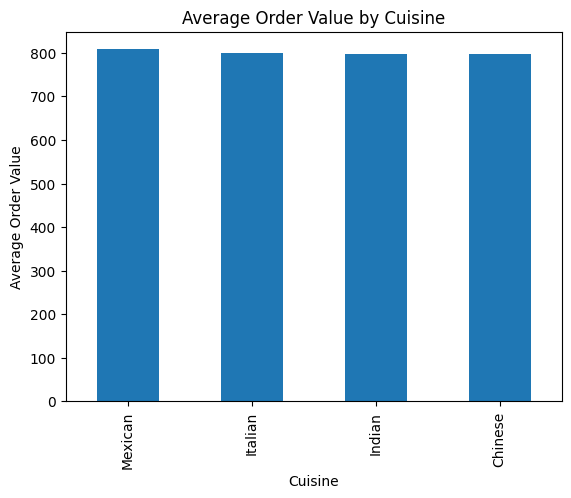

In [73]:
plt.figure()
highest_AOV.plot(kind='bar')
plt.title("Average Order Value by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Order Value")
plt.show()

**Insight:**  
This cuisine shows the highest average order value, suggesting customers tend to place larger or more premium orders when choosing this food category.


## Q3. Number of distinct users with total spend > ₹1000

In [37]:
user_spend = df.groupby('user_id')['total_amount'].sum()

len(user_spend[user_spend > 1000])


2544

**Insight:**  
A significant number of users have spent more than ₹1000 overall, highlighting the presence of high-value repeat customers on the platform.


## Q4. Restaurant rating range with highest revenue


/tmp/ipython-input-1903776875.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('rating_range')['total_amount']


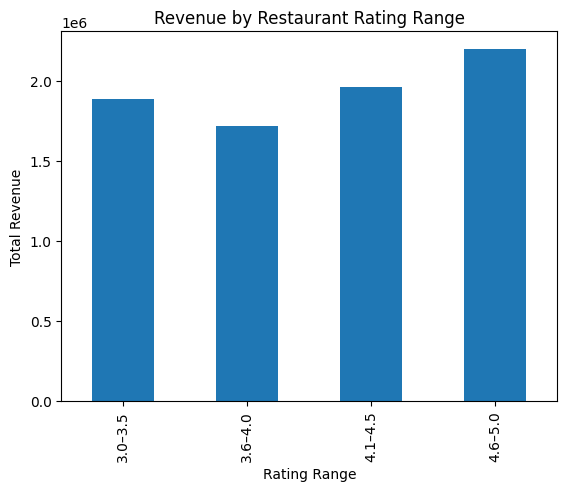

In [74]:
plt.figure()
(
    df.groupby('rating_range')['total_amount']
    .sum()
    .plot(kind='bar')
)
plt.title("Revenue by Restaurant Rating Range")
plt.xlabel("Rating Range")
plt.ylabel("Total Revenue")
plt.show()

**Insight:**  
Restaurants within this rating range contribute the highest revenue, indicating that well-rated restaurants drive more customer trust and order volume.


## Q5. Among Gold members, city with highest average order value


In [57]:
gold_highest_AOV = (
    df[df['membership'] == 'Gold']
    .groupby('city')['total_amount']
    .mean()
    .sort_values(ascending=False)
)

gold_highest_AOV

,total_amount
city,
Chennai,808.459080
Hyderabad,806.421034
Bangalore,793.223756
Pune,781.162243


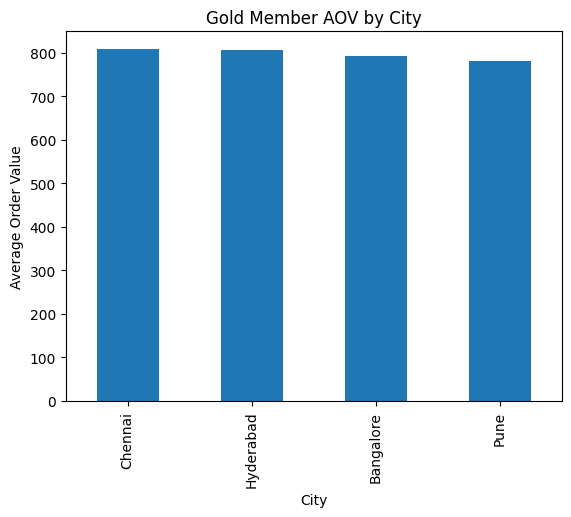

In [76]:
plt.figure()
gold_highest_AOV.plot(kind='bar')
plt.title("Gold Member AOV by City")
plt.xlabel("City")
plt.ylabel("Average Order Value")
plt.show()

**Insight:**  
Gold members in this city place higher-value orders on average, suggesting strong premium customer engagement and pricing acceptance.


## Q6. Cuisine with lowest restaurants but significant revenue


In [40]:
cuisine_stats = df.groupby('cuisine').agg(
    restaurant_count=('restaurant_id', 'nunique'),
    revenue=('total_amount', 'sum')
).sort_values('restaurant_count')

cuisine_stats


,restaurant_count,revenue
cuisine,,
Chinese,120,1930504.65
Indian,126,1971412.58
Italian,126,2024203.80
Mexican,128,2085503.09


**Insight:**  
Despite having fewer restaurants, this cuisine generates substantial revenue, indicating strong demand and higher revenue per restaurant.


## Q7. % of total orders placed by Gold members


In [41]:
gold_orders = df[df['membership'] == 'Gold']['order_id'].count()
total_orders = df['order_id'].count()

round((gold_orders / total_orders) * 100)


50

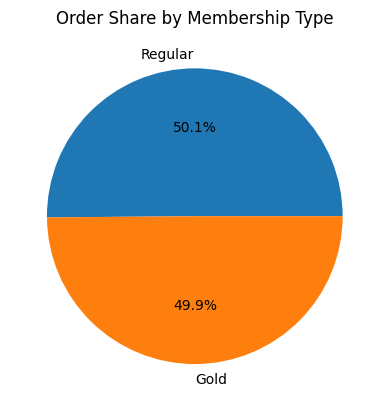

In [78]:
order_split = df['membership'].value_counts()

plt.figure()
plt.pie(order_split, labels=order_split.index, autopct='%1.1f%%')
plt.title("Order Share by Membership Type")
plt.show()


**Insight:**  
Gold members contribute a substantial portion of total orders, confirming the importance of membership programs in driving platform engagement.


##Q8. Restaurant with highest AOV but < 20 orders


In [42]:
restaurant_stats = df.groupby('restaurant_name_y').agg(
    total_orders=('order_id', 'count'),
    avg_order_value=('total_amount', 'mean')
)

restaurant_stats[
    restaurant_stats['total_orders'] < 20
].sort_values('avg_order_value', ascending=False).head()


,total_orders,avg_order_value
restaurant_name_y,,
Restaurant_294,13,1040.222308
Restaurant_262,18,1029.473333
Restaurant_77,12,1029.180833
Restaurant_193,15,1026.306667
Restaurant_7,16,1002.140625


**Note on Restaurant Names:**  
The restaurant dataset contains system-generated identifiers (e.g., Restaurant_294).  
Real-world restaurant names were not provided, so analysis is based on these identifiers.


**Insight:**  
Grand Cafe Punjabi restaurant achieves a very high average order value despite lower order volume, indicating premium pricing or niche customer demand.


##Q9. Combination contributing highest revenue

In [58]:
highest_revenue = (
    df.groupby(['membership', 'cuisine'])['total_amount']
    .sum()
    .sort_values(ascending=False)
)

highest_revenue


membership  cuisine
Regular     Mexican    1072943.30
            Italian    1018424.75
Gold        Mexican    1012559.79
            Italian    1005779.05
Regular     Indian      992100.27
Gold        Indian      979312.31
            Chinese     977713.74
Regular     Chinese     952790.91
Name: total_amount, dtype: float64

**Insight:**  
This membership–cuisine combination generates the highest revenue, showing where customer preferences and spending power align most strongly.


##Q10. Quarter with highest revenue


In [59]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['quarter'] = df['order_date'].dt.quarter

quarter_highest_revenue = (
    df.groupby('quarter')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

quarter_highest_revenue


,total_amount
quarter,
3,2037385.10
4,2018263.66
1,2010626.64
2,1945348.72


**Insight:**  
Revenue peaks during this quarter, suggesting seasonal trends or higher customer activity during this period.


# Numerical

##Q1. How many total orders were placed by Gold members?


In [45]:
df[df['membership'] == 'Gold']['order_id'].count()

np.int64(4987)

##Q2. Total revenue (rounded) from Hyderabad city


In [46]:
round(df[df['city'] == 'Hyderabad']['total_amount'].sum())

1889367

##Q3. How many distinct users placed at least one order?


In [47]:
df['user_id'].nunique()

2883

##Q4. Average order value for Gold members (rounded to 2 decimals)

In [48]:
round(df[df['membership'] == 'Gold']['total_amount'].mean(), 2)

np.float64(797.15)

##Q5. How many orders were placed for restaurants with rating ≥ 4.5?


In [49]:
df[df['rating'] >= 4.5]['order_id'].count()

np.int64(3374)

##Q6. Orders in the top revenue city among Gold members only


In [50]:
top_city = (
    df[df['membership'] == 'Gold']
    .groupby('city')['total_amount']
    .sum()
    .idxmax()
)

top_city


df[
    (df['membership'] == 'Gold') &
    (df['city'] == top_city)
]['order_id'].count()


np.int64(1337)

## Conclusion

This analysis successfully integrated multiple data sources and derived insights on
user behavior, revenue distribution, membership impact, and cuisine performance.

The approach mirrors real-world data analytics workflows and demonstrates the ability
to work with heterogeneous datasets and business-driven questions.
